# Pairwise Consistency Model — Unified Physical-Diffusion Timeline (GP / SPDE)

Adapts the dynamical-systems consistency model to SPDE Gaussian Process data  
using the unified diffusion-physical timeline theory.

## 📖 Theory — Physical and Learned Consistency Regimes

Inference is performed along a single continuous variable $t \in [0,1]$ (the *diffusion time*).  
A transition point $t_\mathrm{IC} \in (0,1)$ separates two regimes:

| Regime | Interval | Role |
|--------|----------|------|
| **Spin-up (diffusion)** | $[0,\,t_\mathrm{IC}]$ | Denoising toward the initial physical condition $\mathbf{x}_0$ |
| **Physical** | $[t_\mathrm{IC},\,1]$ | Trajectory evolution supervised by physical states $\{\mathbf{x}_k\}$ |

### Spin-up regime — $t \le t_\mathrm{IC}$

The model starts from noisy initialisation $\mathbf{x}^{(0)} \sim \mathcal{N}(0,I)$ and is trained so that

$$g_\theta\!\left(\mathbf{x}^{(t)}, t, 0, \mathbf{y}\right) \;\approx\; \mathbf{x}_0, \qquad \mathbf{x}^{(t)} = \mathbf{x}_0 + \sigma(t)\,\mathbf{z}.$$

The noise schedule $\sigma:[0,t_\mathrm{IC}]\!\to\![0,\sigma_\mathrm{noise}]$ follows the Karras schedule.

### Physical regime — $t \ge t_\mathrm{IC}$

Diffusion time is identified with physical time via

$$t_k = t_\mathrm{IC} + (1-t_\mathrm{IC})\,\frac{k}{N}, \qquad k=0,\dots,N,$$

so that $\mathbf{x}^{(t_k)} \approx \mathbf{x}_k$.  
No forward stochastic process is needed: the model is supervised directly by

$$g_\theta\!\left(\mathbf{x}_k, t_k, t_{k'}, \mathbf{y}\right) \;\approx\; \mathbf{x}_k - \mathbf{x}_{k'}.$$

### Pairwise consistency across the unified timeline

$$\mathbf{x}^{(t')} = \mathbf{x}^{(t)} - \alpha(t,t')\,g_\theta\!\left(\mathbf{x}^{(t)}, t, t', \mathbf{y}\right),$$

with three training pairs:
- **Diffusion–diffusion**: $t, t' \le t_\mathrm{IC}$  
- **Physical–physical**: $t, t' \ge t_\mathrm{IC}$  
- **Cross-regime**: $t < t_\mathrm{IC} < t'$

### Conditioning

$g_\theta$ is conditioned on the *full* observation window $\mathbf{y} = \{\mathbf{y}_0,\dots,\mathbf{y}_N\}$,  
corresponding to a smoothing formulation (4DVar / Kalman smoother analogy).

## 🛠️ Setup

### GPU Check

In [1]:
!nvidia-smi

Fri Apr 24 08:54:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 555.42.02              Driver Version: 555.42.02      CUDA Version: 12.5     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A40                     Off |   00000000:4A:00.0 Off |                    0 |
|  0%   25C    P8             24W /  300W |       1MiB /  46068MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
%env CUDA_VISIBLE_DEVICES=1

env: CUDA_VISIBLE_DEVICES=1


### Imports

In [ ]:
import json
import math
import os
import glob
from dataclasses import asdict, dataclass
from typing import Any, Callable, List, Optional, Tuple, Union

import numpy as np
import xarray as xr
import pandas as pd
import torch
from einops import rearrange
from einops.layers.torch import Rearrange
import pytorch_lightning as pl
from pytorch_lightning import LightningModule, Trainer, seed_everything
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint
from pytorch_lightning.loggers import TensorBoardLogger
from matplotlib import pyplot as plt
from torch import Tensor, nn
from torch.nn import functional as F
from torchinfo import summary

import sys
sys.path.append('../..')    # -> consistency/
sys.path.append('../../..')  # -> 4dvarnet-starter-devs/

from consistency_models.consistency_models_DynCM import (
    ConsistencyTrainingDynamicalSystems,
    ConsistencySamplingAndEditingDynamicalSystems,
    model_dynamical_systems_forward_wrapper,
    compute_sigma,
)
from consistency_models.consistency_models_CM import (
    ema_decay_rate_schedule,
)
from consistency_models.utils import update_ema_model_

## 🧠 Implementation

### DataModule — SPDE Diffusion Dataset

$N = $ `window_size` physical time steps.  
The transition point is $t_\mathrm{IC} = 1/N$ (one Karras step for spin-up, $N-1$ for physical evolution).

In [4]:
from src.data_notebook_spde import SPDEDataModule

SPDE_PATH = "/data/users/maxb/4dvarnet-starter-devs/SPDE/SPDE_diffusion_dataset_1.nc"

ds_inspect = xr.open_dataset(SPDE_PATH)
print(ds_inspect)
print("\nVariables:")
for v in ds_inspect.data_vars:
    print(f"  {v}: {ds_inspect[v].dims}  shape={ds_inspect[v].shape}  dtype={ds_inspect[v].dtype}")
ds_inspect.close()

<xarray.Dataset> Size: 79MB
Dimensions:    (time: 300, lat: 128, lon: 128)
Coordinates:
  * lon        (lon) int64 1kB 0 1 2 3 4 5 6 7 ... 121 122 123 124 125 126 127
  * lat        (lat) int64 1kB 0 1 2 3 4 5 6 7 ... 121 122 123 124 125 126 127
  * time       (time) int64 2kB 0 1 2 3 4 5 6 7 ... 293 294 295 296 297 298 299
Data variables:
    x          (time, lat, lon) float32 20MB ...
    y          (time, lat, lon) float32 20MB ...
    OI         (time, lat, lon) float64 39MB ...
    H11        (lat, lon) float32 66kB ...
    H22        (lat, lon) float32 66kB ...
    H12        (lat, lon) float32 66kB ...
    Time       (time) int64 2kB ...
    longitude  (lon) int64 1kB ...
    latitude   (lat) int64 1kB ...
Attributes:
    description:  SPDE-based diffusion GP

Variables:
  x: ('time', 'lat', 'lon')  shape=(300, 128, 128)  dtype=float32
  y: ('time', 'lat', 'lon')  shape=(300, 128, 128)  dtype=float32
  OI: ('time', 'lat', 'lon')  shape=(300, 128, 128)  dtype=float64
  H11: ('la

[SPDEDataModule] T=300, window=5, stride=1 → 296 windows: train=207, val=44, test=45
[SPDEDataModule] Norm stats (mean, std): (-0.00018237734911963344, 0.249156191945076)
window_size C      = 5
t_IC (transition)  = 0.2000  (= 1/C)
Spatial size       = 128 x 128
TrainingItem: input (y) (5, 128, 128)  tgt (x) (5, 128, 128)
window_size C      = 5
t_IC (transition)  = 0.2000  (= 1/C)
Spatial size       = 128 x 128
TrainingItem: input (y) (5, 128, 128)  tgt (x) (5, 128, 128)


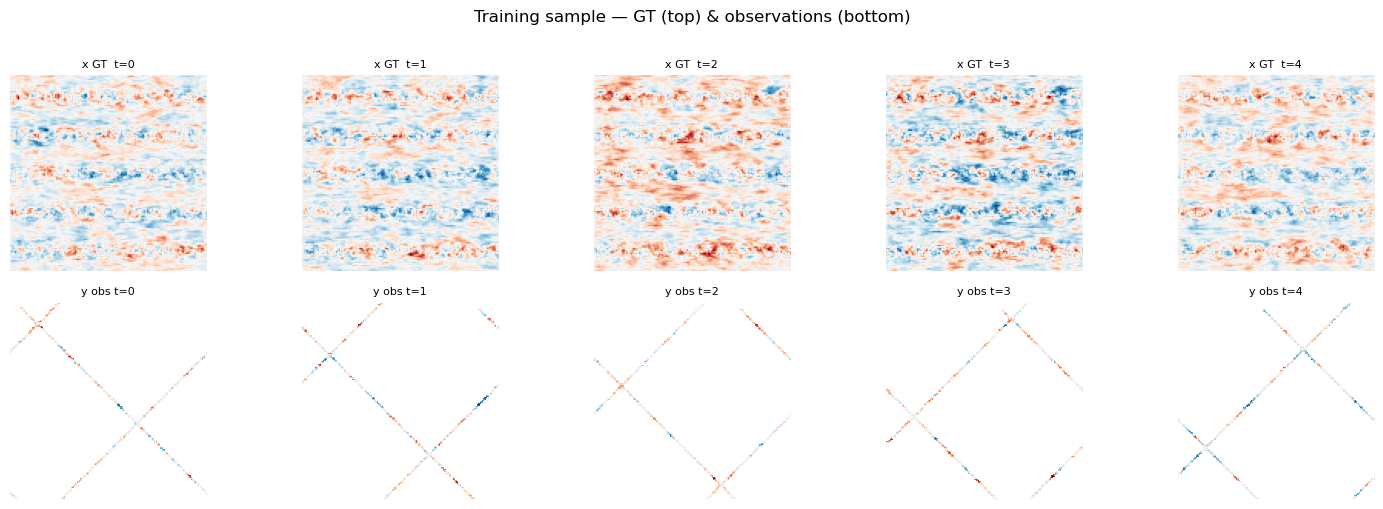

In [5]:
datamodule = SPDEDataModule(
    path=SPDE_PATH,
    window_size=5,
    stride=1,
    train_ratio=0.7,
    val_ratio=0.15,
    dl_kw={"batch_size": 1, "num_workers": 1},
)
datamodule.setup()

sample = datamodule.train_ds[0]
C  = datamodule.window_size
H, W = sample.tgt.shape[-2], sample.tgt.shape[-1]
t_IC = 1.0 / C   # transition point between spin-up and physical regime

print(f"window_size C      = {C}")
print(f"t_IC (transition)  = {t_IC:.4f}  (= 1/C)")
print(f"Spatial size       = {H} x {W}")
print(f"TrainingItem: input (y) {sample.input.shape}  tgt (x) {sample.tgt.shape}")

fig, axes = plt.subplots(2, C, figsize=(3 * C, 5))
for t_idx in range(C):
    axes[0, t_idx].imshow(sample.tgt[t_idx],   origin="lower", cmap="RdBu_r")
    axes[0, t_idx].set_title(f"x GT  t={t_idx}", fontsize=8)
    axes[0, t_idx].axis("off")
    axes[1, t_idx].imshow(sample.input[t_idx], origin="lower", cmap="RdBu_r")
    axes[1, t_idx].set_title(f"y obs t={t_idx}", fontsize=8)
    axes[1, t_idx].axis("off")
plt.suptitle("Training sample — GT (top) & observations (bottom)", y=1.01)
plt.tight_layout()
plt.show()

### UNet Building Blocks

The UNet takes:
- **x**: `(B, 1, H, W)` — current state at diffusion time $t$ (single physical field)
- **y**: `(B, C, H, W)` — full observation window (all $N$ time steps) — `NaN` = unobserved
- **mask**: `(B, C, H, W)` — binary mask derived from `y`
- **t, t'**: `(B,)` — current and target diffusion times

Total input channels = $1 + C + C = 2C + 1$.  
Output = `(B, 1, H, W)` — predicted state at $t'$.

Spatial size 100×100 is padded to the nearest multiple of 8 before the forward pass.

In [6]:
def GroupNorm(channels: int) -> nn.GroupNorm:
    return nn.GroupNorm(num_groups=min(32, channels // 4), num_channels=channels)


class SelfAttention(nn.Module):
    def __init__(self, in_channels: int, out_channels: int,
                 n_heads: int = 8, dropout: float = 0.3) -> None:
        super().__init__()
        self.dropout = dropout
        self.qkv_projection = nn.Sequential(
            GroupNorm(in_channels),
            nn.Conv2d(in_channels, 3 * in_channels, kernel_size=1, bias=False),
            Rearrange("b (i h d) x y -> i b h (x y) d", i=3, h=n_heads),
        )
        self.output_projection = nn.Sequential(
            Rearrange("b h l d -> b l (h d)"),
            nn.Linear(in_channels, out_channels, bias=False),
            Rearrange("b l d -> b d l"),
            GroupNorm(out_channels),
            nn.Dropout1d(dropout),
        )
        self.residual_projection = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x: Tensor) -> Tensor:
        q, k, v = self.qkv_projection(x).unbind(dim=0)
        output = F.scaled_dot_product_attention(
            q, k, v, dropout_p=self.dropout if self.training else 0.0, is_causal=False
        )
        output = self.output_projection(output)
        output = rearrange(output, "b c (x y) -> b c x y", x=x.shape[-2], y=x.shape[-1])
        return output + self.residual_projection(x)


class UNetBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int,
                 time_level_channels: int, dropout: float = 0.3) -> None:
        super().__init__()
        self.input_projection = nn.Sequential(
            GroupNorm(in_channels), nn.SiLU(),
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding="same"),
            nn.Dropout2d(dropout),
        )
        self.time_level_projection = nn.Sequential(
            nn.SiLU(),
            nn.Conv2d(time_level_channels, out_channels, kernel_size=1),
        )
        self.output_projection = nn.Sequential(
            GroupNorm(out_channels), nn.SiLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding="same"),
            nn.Dropout2d(dropout),
        )
        self.residual_projection = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x: Tensor, time_level: Tensor) -> Tensor:
        h = self.input_projection(x)
        h = h + self.time_level_projection(time_level)
        return self.output_projection(h) + self.residual_projection(x)


class UNetBlockWithSelfAttention(nn.Module):
    def __init__(self, in_channels: int, out_channels: int,
                 time_level_channels: int, n_heads: int = 8, dropout: float = 0.3) -> None:
        super().__init__()
        self.unet_block = UNetBlock(in_channels, out_channels, time_level_channels, dropout)
        self.self_attention = SelfAttention(out_channels, out_channels, n_heads, dropout)

    def forward(self, x: Tensor, time_level: Tensor) -> Tensor:
        return self.self_attention(self.unet_block(x, time_level))


class Downsample(nn.Module):
    def __init__(self, channels: int) -> None:
        super().__init__()
        self.projection = nn.Sequential(
            Rearrange("b c (h ph) (w pw) -> b (c ph pw) h w", ph=2, pw=2),
            nn.Conv2d(4 * channels, channels, kernel_size=1),
        )

    def forward(self, x: Tensor) -> Tensor:
        return self.projection(x)


class Upsample(nn.Module):
    def __init__(self, channels: int) -> None:
        super().__init__()
        self.projection = nn.Sequential(
            nn.Upsample(scale_factor=2.0, mode="nearest"),
            nn.Conv2d(channels, channels, kernel_size=3, padding="same"),
        )

    def forward(self, x: Tensor) -> Tensor:
        return self.projection(x)


class TimeEmbedding(nn.Module):
    """Fourier embedding for a scalar t ∈ [0,1]."""
    def __init__(self, channels: int, scale: float = 16.0) -> None:
        super().__init__()
        self.W = nn.Parameter(torch.randn(channels // 2) * scale, requires_grad=False)
        self.projection = nn.Sequential(
            nn.Linear(channels, 4 * channels),
            nn.SiLU(),
            nn.Linear(4 * channels, channels),
            Rearrange("b c -> b c () ()"),
        )

    def forward(self, x: Tensor) -> Tensor:
        h = x[:, None] * self.W[None, :] * 2 * torch.pi
        h = torch.cat([torch.sin(h), torch.cos(h)], dim=-1)
        return self.projection(h)


# ---- Spatial padding (100×100 → 104×104, multiple of 8) ----
def _pad_to_multiple(x: Tensor, multiple: int = 8) -> Tuple[Tensor, Tuple[int, int, int, int]]:
    _, _, H, W = x.shape
    pad_h = (multiple - H % multiple) % multiple
    pad_w = (multiple - W % multiple) % multiple
    padding = (0, pad_w, 0, pad_h)
    return F.pad(x, padding, mode="reflect"), padding


def _unpad(x: Tensor, padding: Tuple[int, int, int, int]) -> Tensor:
    _, pad_w, _, pad_h = padding
    H, W = x.shape[-2], x.shape[-1]
    return x[..., :H - pad_h if pad_h else H, :W - pad_w if pad_w else W]

### UNet

Input: `cat(x, y_filled, mask_y)` → $2C+1$ channels, output: `1` channel.  
Two separate `TimeEmbedding` for $t$ and $t'$, concatenated → $2 \times$ `time_level_channels` conditioning.

In [7]:
@dataclass
class UNetConfig:
    # channels = C = window_size (number of physical time steps)
    channels: int = 5
    time_level_channels: int = 128
    time_level_scale: float = 16.0
    n_heads: int = 8
    top_blocks_channels: Tuple[int, ...] = (64, 64)
    top_blocks_n_blocks_per_resolution: Tuple[int, ...] = (2, 2)
    top_blocks_has_resampling: Tuple[bool, ...] = (True, True)
    top_blocks_dropout: Tuple[float, ...] = (0.0, 0.0)
    mid_blocks_channels: Tuple[int, ...] = (128, 256)
    mid_blocks_n_blocks_per_resolution: Tuple[int, ...] = (4, 4)
    mid_blocks_has_resampling: Tuple[bool, ...] = (True, False)
    mid_blocks_dropout: Tuple[float, ...] = (0.0, 0.0)


class UNet(nn.Module):
    """
    UNet for the unified physical-diffusion consistency model.

    Forward signature: UNet(x, y, t, t_prime)
      x       : (B, 1,   H, W)  -- current state at diffusion time t (spin-up or physical)
      y       : (B, C,   H, W)  -- full observation window (NaN = unobserved)
      t       : (B,)            -- current diffusion time
      t_prime : (B,)            -- target diffusion time

    Input channels = 2*C + 1  (x | y_filled | mask_y)
    Output         = 1 channel (predicted state at t')
    """
    def __init__(self, config: UNetConfig) -> None:
        super().__init__()
        self.config = config
        C   = config.channels
        top = config.top_blocks_channels[0]

        # input: cat(x:1, y_filled:C, mask_y:C) = 2C+1 channels
        self.input_projection = nn.Conv2d(2 * C + 1, top, kernel_size=3, padding="same")

        # Separate embeddings for t and t'
        self.time_embedding_t  = TimeEmbedding(config.time_level_channels, config.time_level_scale)
        self.time_embedding_tp = TimeEmbedding(config.time_level_channels, config.time_level_scale)

        self.top_encoder_blocks = self._make_encoder_blocks(
            config.top_blocks_channels + config.mid_blocks_channels[:1],
            config.top_blocks_n_blocks_per_resolution,
            config.top_blocks_has_resampling,
            config.top_blocks_dropout, self._make_top_block,
        )
        self.mid_encoder_blocks = self._make_encoder_blocks(
            config.mid_blocks_channels + config.mid_blocks_channels[-1:],
            config.mid_blocks_n_blocks_per_resolution,
            config.mid_blocks_has_resampling,
            config.mid_blocks_dropout, self._make_mid_block,
        )
        self.mid_decoder_blocks = self._make_decoder_blocks(
            config.mid_blocks_channels + config.mid_blocks_channels[-1:],
            config.mid_blocks_n_blocks_per_resolution,
            config.mid_blocks_has_resampling,
            config.mid_blocks_dropout, self._make_mid_block,
        )
        self.top_decoder_blocks = self._make_decoder_blocks(
            config.top_blocks_channels + config.mid_blocks_channels[:1],
            config.top_blocks_n_blocks_per_resolution,
            config.top_blocks_has_resampling,
            config.top_blocks_dropout, self._make_top_block,
        )
        # Output: 1 channel (single physical state)
        self.output_projection = nn.Conv2d(top, 1, kernel_size=3, padding="same")

    def forward(self, x: Tensor, y: Tensor,
                t: Tensor, t_prime: Tensor) -> Tensor:
        """
        x       : (B, 1,   H, W)
        y       : (B, C,   H, W)   -- NaN where unobserved
        t       : (B,)
        t_prime : (B,)
        """
        mask_y  = (~torch.isnan(y)).to(dtype=x.dtype)
        y_fill  = torch.nan_to_num(y, nan=0.0)

        # Concatenate along channel dim and pad to multiple of 8
        inp = torch.cat([x, y_fill, mask_y], dim=1)   # (B, 2C+1, H, W)
        inp, padding = _pad_to_multiple(inp, multiple=8)

        h = self.input_projection(inp)

        emb_t  = self.time_embedding_t(t)
        emb_tp = self.time_embedding_tp(t_prime)
        time_level = torch.cat([emb_t, emb_tp], dim=1)   # (B, 2*TLC, 1, 1)

        top_encoder_embeddings = []
        for block in self.top_encoder_blocks:
            if isinstance(block, UNetBlock):
                h = block(h, time_level)
                top_encoder_embeddings.append(h)
            else:
                h = block(h)

        mid_encoder_embeddings = []
        for block in self.mid_encoder_blocks:
            if isinstance(block, UNetBlockWithSelfAttention):
                h = block(h, time_level)
                mid_encoder_embeddings.append(h)
            else:
                h = block(h)

        for block in self.mid_decoder_blocks:
            if isinstance(block, UNetBlockWithSelfAttention):
                h = torch.cat((h, mid_encoder_embeddings.pop()), dim=1)
                h = block(h, time_level)
            else:
                h = block(h)

        for block in self.top_decoder_blocks:
            if isinstance(block, UNetBlock):
                h = torch.cat((h, top_encoder_embeddings.pop()), dim=1)
                h = block(h, time_level)
            else:
                h = block(h)

        out = self.output_projection(h)
        return _unpad(out, padding)

    # ---- builder helpers ----
    def _make_encoder_blocks(self, channels, n_blocks, has_resampling, dropout, block_fn):
        blocks = nn.ModuleList()
        for idx, (ic, oc) in enumerate(zip(channels[:-1], channels[1:])):
            for _ in range(n_blocks[idx]):
                blocks.append(block_fn(ic, oc, dropout[idx]))
                ic = oc
            if has_resampling[idx]:
                blocks.append(Downsample(oc))
        return blocks

    def _make_decoder_blocks(self, channels, n_blocks, has_resampling, dropout, block_fn):
        blocks = nn.ModuleList()
        for idx, (oc, ic) in enumerate(list(zip(channels[:-1], channels[1:]))[::-1]):
            if has_resampling[::-1][idx]:
                blocks.append(Upsample(ic))
            inner = []
            for _ in range(n_blocks[::-1][idx]):
                inner.append(block_fn(ic * 2, oc, dropout[::-1][idx]))
                oc = ic
            blocks.extend(inner[::-1])
        return blocks

    def _make_top_block(self, ic, oc, dropout):
        return UNetBlock(ic, oc, 2 * self.config.time_level_channels, dropout)

    def _make_mid_block(self, ic, oc, dropout):
        return UNetBlockWithSelfAttention(
            ic, oc, 2 * self.config.time_level_channels, self.config.n_heads, dropout
        )

    def save_pretrained(self, pretrained_path: str) -> None:
        os.makedirs(pretrained_path, exist_ok=True)
        with open(os.path.join(pretrained_path, "config.json"), mode="w") as f:
            json.dump(asdict(self.config), f)
        torch.save(self.state_dict(), os.path.join(pretrained_path, "model.pt"))

    @classmethod
    def from_pretrained(cls, pretrained_path: str) -> "UNet":
        with open(os.path.join(pretrained_path, "config.json"), mode="r") as f:
            config_dict = json.load(f)
        model = cls(UNetConfig(**config_dict))
        model.load_state_dict(
            torch.load(os.path.join(pretrained_path, "model.pt"), map_location="cpu")
        )
        return model


# ---- Sanity check ----
C = datamodule.window_size
_unet = UNet(UNetConfig(channels=C)).cpu()
summary(
    _unet,
    input_size=(
        (1, 1,   100, 100),  # x  (current state, 1 channel)
        (1, C,   100, 100),  # y  (full obs window, C channels)
        (1,),                # t
        (1,),                # t'
    ),
    col_names=["input_size", "output_size", "num_params"],
    verbose=0,
)
_unet = _unet.cpu()   # bring back to CPU after torchinfo

# Quick forward
_x = torch.randn(1, 1, 100, 100)
_y = torch.randn(1, C, 100, 100)
_y[0, :, :5, :5] = float("nan")   # some NaN observations
_t = torch.rand(1)
with torch.no_grad():
    _out = _unet(_x, _y, _t, _t)
print(f"[OK] UNet forward: x {_x.shape} + y {_y.shape} -> {_out.shape}")

[OK] UNet forward: x torch.Size([1, 1, 100, 100]) + y torch.Size([1, 5, 100, 100]) -> torch.Size([1, 1, 100, 100])


### LightningModule

Wraps `ConsistencyTrainingDynamicalSystems` from the existing module.  
The training routine already implements the dual-regime logic:
- $t \le t_\mathrm{IC}$: noisy IC → `compute_sigma` schedule + skip-connection spinup weight → 0
- $t > t_\mathrm{IC}$: physical state interpolation, `skip_spinup` → 0 (model output directly)

In [8]:

@dataclass
class LitConsistencyModelConfig:
    initial_ema_decay_rate: float = 0.95
    student_model_ema_decay_rate: float = 0.99993
    lr: float = 1e-4
    betas: Tuple[float, float] = (0.9, 0.995)
    lr_scheduler_start_factor: float = 1e-5
    lr_scheduler_iters: int = 10_000
    total_training_steps: int = 10_000   # N_steps for timestep schedule 3 -> final_timesteps


class LitConsistencyModel(LightningModule):
    """
    Lightning wrapper for the unified physical-diffusion consistency model.

    Training regime logic is handled by ConsistencyTrainingDynamicalSystems:
      - spin-up  (t ≤ t_IC=1/C): noisy IC with Karras sigma, c_skip/c_out residual
      - physical (t >  t_IC)   : physical state interpolation, skip_spinup → direct model output

    The model observes the FULL observation window y at every step (smoothing formulation).

    ── Field mapping in ConsistencyTrainingOutputFewSteps ──────────────────
    ConsistencyTrainingDynamicalSystems returns 5 positional args:
      (next_from_intermediate_x, intermediate_from_current_x,
       next_from_current_x, num_timesteps, steps)
    which map to dataclass fields as:
      predicted_next_from_intermediate ← next_from_intermediate_x   (student t_int→t_next)
      target_next_from_current         ← intermediate_from_current_x (student t_cur→t_int — unused)
      num_timesteps                    ← next_from_current_x         (TEACHER t_cur→t_next, spatial tensor)
      sigmas                           ← num_timesteps               (int — actual N)
      loss_weights                     ← steps                       (time grid Tensor)

    Consistency loss: student(t_int → t_next)  ≈  teacher(t_cur → t_next)
      = MSE(output.predicted_next_from_intermediate,  output.num_timesteps)
    ────────────────────────────────────────────────────────────────────────
    """
    def __init__(
        self,
        consistency_training: ConsistencyTrainingDynamicalSystems,
        student_model: UNet,
        teacher_model: UNet,
        ema_student_model: UNet,
        config: LitConsistencyModelConfig,
    ) -> None:
        super().__init__()
        self.consistency_training = consistency_training
        self.student_model        = student_model
        self.teacher_model        = teacher_model
        self.ema_student_model    = ema_student_model
        self.config               = config
        self.num_timesteps        = consistency_training.initial_timesteps

        for param in self.teacher_model.parameters():
            param.requires_grad = False
        for param in self.ema_student_model.parameters():
            param.requires_grad = False
        self.teacher_model     = self.teacher_model.eval()
        self.ema_student_model = self.ema_student_model.eval()

    def training_step(self, batch, batch_idx: int):
        if isinstance(batch, list):
            batch = batch[0]

        output = self.consistency_training(
            self.student_model,
            self.teacher_model,
            batch.tgt,
            batch.input,
            self.global_step,
            self.config.total_training_steps,
        )

        # Due to positional arg mismatch, the actual num_timesteps (int) is in output.sigmas
        num_ts = output.sigmas
        if isinstance(num_ts, torch.Tensor):
            num_ts = int(num_ts.item()) if num_ts.numel() == 1 else self.num_timesteps
        self.num_timesteps = num_ts

        # ── Consistency loss ──────────────────────────────────────────────
        # student(intermediate → next)  vs  teacher(current → next)
        #   output.predicted_next_from_intermediate = student output (t_int→t_next)
        #   output.num_timesteps                    = teacher output (t_cur→t_next)
        #                                             (spatial tensor due to field mismatch)
        student_pred  = output.predicted_next_from_intermediate
        teacher_target = output.num_timesteps   # teacher next_from_current_x (no_grad)
        loss = F.mse_loss(student_pred, teacher_target.detach())

        if batch_idx % 20 == 0:
            # output.loss_weights holds the actual time grid tensor (steps)
            grid = output.loss_weights
            if isinstance(grid, torch.Tensor) and grid.numel() > 1:
                grid_str = f"[{grid[0].item():.3f}…{grid[-1].item():.3f}]"
            else:
                grid_str = f"N={self.num_timesteps}"
            print(
                f"[Ep {self.current_epoch} | step {self.global_step}]  "
                f"N={self.num_timesteps}  loss={loss.item():.5f}  t_grid={grid_str}"
            )

        self.log_dict({
            "train_loss":    loss,
            "num_timesteps": float(self.num_timesteps),
        }, prog_bar=False)
        return loss

    def on_train_batch_end(self, outputs, batch, batch_idx: int) -> None:
        ema_rate = ema_decay_rate_schedule(
            self.num_timesteps,
            self.config.initial_ema_decay_rate,
            self.consistency_training.initial_timesteps,
        )
        update_ema_model_(self.teacher_model,     self.student_model, ema_rate)
        update_ema_model_(self.ema_student_model, self.student_model,
                          self.config.student_model_ema_decay_rate)
        self.log("ema_decay_rate", ema_rate)

    def configure_optimizers(self):
        opt = torch.optim.Adam(
            self.student_model.parameters(),
            lr=self.config.lr, betas=self.config.betas,
        )
        sched = torch.optim.lr_scheduler.LinearLR(
            opt,
            start_factor=self.config.lr_scheduler_start_factor,
            total_iters=self.config.lr_scheduler_iters,
        )
        return [opt], [{"scheduler": sched, "interval": "step", "frequency": 1}]


## 🚀 Training

### Unified timeline — time grid visualisation

Before training, let's visualise the unified time grid $\{t_0,\dots,t_N\}$ for a given
`num_timesteps` to see how the Karras grid partitions the spin-up and physical regimes.

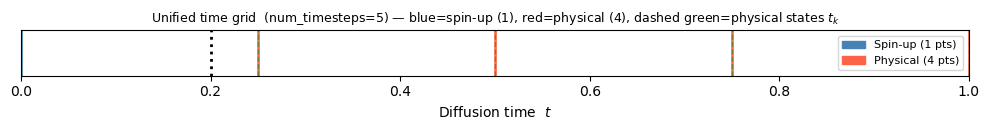

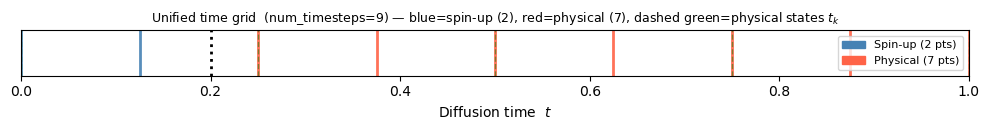

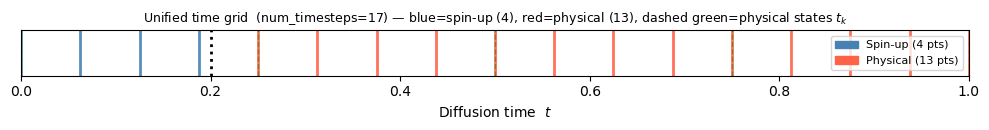

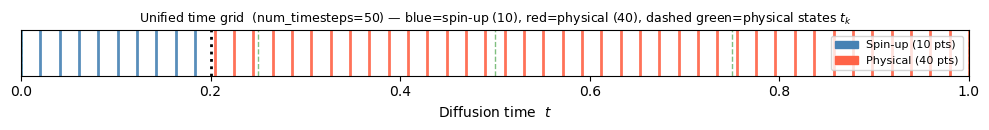

In [ ]:
from consistency_models.consistency_models_DynCM import compute_sigma
from consistency_models.utils import karras_schedule

C_vis        = datamodule.window_size
t_IC_vis     = 1.0 / C_vis
SIGMA_MIN    = 0.002
SIGMA_MAX    = 80.0
RHO          = 7.0

for num_t in [5, 9, 17, 50]:
    grid = karras_schedule(num_t, SIGMA_MIN, SIGMA_MAX, RHO, torch.device("cpu"), as_time=True)
    physical_ts = torch.linspace(0, 1, C_vis)

    n_spinup  = (grid <= t_IC_vis).sum().item()
    n_phys    = (grid > t_IC_vis).sum().item()

    fig, ax = plt.subplots(figsize=(10, 1.4))
    for i, t_val in enumerate(grid.tolist()):
        color = "steelblue" if t_val <= t_IC_vis else "tomato"
        ax.axvline(t_val, color=color, linewidth=2, alpha=0.9)
    for t_phys in physical_ts.tolist():
        ax.axvline(t_phys, color="green", linewidth=1, linestyle="--", alpha=0.5)
    ax.axvline(t_IC_vis, color="black", linewidth=2, linestyle=":", label=f"$t_{{IC}}={t_IC_vis:.2f}$")
    ax.set_xlim(0, 1)
    ax.set_yticks([])
    ax.set_xlabel("Diffusion time  $t$")
    ax.set_title(
        f"Unified time grid  (num_timesteps={num_t}) — "
        f"blue=spin-up ({n_spinup}), red=physical ({n_phys}), "
        f"dashed green=physical states $t_k$",
        fontsize=9,
    )
    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(color="steelblue", label=f"Spin-up ({n_spinup} pts)"),
        Patch(color="tomato",    label=f"Physical ({n_phys} pts)"),
    ], loc="upper right", fontsize=8)
    plt.tight_layout()
    plt.show()

### TensorBoard

In [10]:
%tensorboard --logdir=logs_CT_DynCM_spde --port 6010

UsageError: Line magic function `%tensorboard` not found.


### Training Loop

In [11]:
import shutil

RESET_TRAINING   = True    # Reset: bugs fixed (linspace grid + teacher input fix)
RESUME_FROM_LAST = True    # True = prefer last.ckpt over best train_loss ckpt

LOG_DIR     = "logs_CT_DynCM_spde"
LOG_VERSION = "v1"
CKPT_DIR    = os.path.join(LOG_DIR, LOG_VERSION, "checkpoints")
MODEL_PATH  = os.path.join(LOG_DIR, LOG_VERSION, "best_model")


def _is_valid_checkpoint(path: str) -> bool:
    try:
        ckpt  = torch.load(path, map_location="cpu")
        state = ckpt.get("state_dict", {})
        return all(
            not (torch.is_tensor(v) and torch.isnan(v).any())
            for v in state.values()
        )
    except Exception:
        return False


def find_resume_ckpt(ckpt_dir: str, use_last: bool = True) -> Optional[str]:
    if not os.path.isdir(ckpt_dir):
        return None
    if use_last:
        last = os.path.join(ckpt_dir, "last.ckpt")
        if os.path.isfile(last) and _is_valid_checkpoint(last):
            print(f"[OK] Resuming from: {last}")
            return last
        print("[WARN] last.ckpt missing or invalid — scanning for best valid checkpoint.")
    candidates = sorted(
        [p for p in glob.glob(os.path.join(ckpt_dir, "*.ckpt"))
         if "last" not in os.path.basename(p) and "train_loss=" in os.path.basename(p)],
        key=lambda p: float(os.path.basename(p).split("train_loss=")[-1].replace(".ckpt", "")),
    )
    for p in candidates:
        if _is_valid_checkpoint(p):
            loss_val = float(os.path.basename(p).split("train_loss=")[-1].replace(".ckpt", ""))
            print(f"[OK] Best valid checkpoint: {p}  (train_loss={loss_val:.4f})")
            return p
    print("[WARN] No valid checkpoint found — starting from scratch.")
    return None


if RESET_TRAINING:
    for d in [CKPT_DIR, MODEL_PATH]:
        if os.path.exists(d):
            shutil.rmtree(d)
            print(f"[DELETE] {d}")
    resume_ckpt = None
else:
    resume_ckpt = find_resume_ckpt(CKPT_DIR, use_last=RESUME_FROM_LAST)

# ---- Models ----
C = datamodule.window_size
student_model     = UNet(UNetConfig(channels=C))
teacher_model     = UNet(UNetConfig(channels=C))
ema_student_model = UNet(UNetConfig(channels=C))
teacher_model.load_state_dict(student_model.state_dict())
ema_student_model.load_state_dict(student_model.state_dict())

# ---- Training ----
ct = ConsistencyTrainingDynamicalSystems(
    sigma_min=0.002,
    sigma_max=80.0,
    rho=7.0,
    sigma_data=1.0,
    initial_timesteps=5,
    final_timesteps=17,
)

lit_cm = LitConsistencyModel(
    ct,
    student_model,
    teacher_model,
    ema_student_model,
    LitConsistencyModelConfig(
        lr_scheduler_iters=1000,
        total_training_steps=10_000,
    ),
)

trainer = Trainer(
    accelerator="gpu",
    max_epochs=500,
    accumulate_grad_batches=4,
    precision="bf16-mixed",
    gradient_clip_val=1.0,
    gradient_clip_algorithm="norm",
    log_every_n_steps=1,
    logger=TensorBoardLogger(".", name=LOG_DIR, version=LOG_VERSION),
    callbacks=[
        LearningRateMonitor(logging_interval="step"),
        ModelCheckpoint(
            dirpath=CKPT_DIR,
            monitor="train_loss",
            save_top_k=3,
            save_last=True,
            filename="{epoch:03d}-{step}-{train_loss:.4f}",
        ),
    ],
)

seed_everything(42)
trainer.fit(lit_cm, datamodule, ckpt_path=resume_ckpt)

# Save EMA model
lit_cm.ema_student_model.save_pretrained(MODEL_PATH)
print(f"[OK] EMA model saved → {MODEL_PATH}")


[DELETE] logs_CT_DynCM_spde/v1/checkpoints
[DELETE] logs_CT_DynCM_spde/v1/best_model


Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
Global seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
Global seed set to 42
/dmidata/users/maxb/conda/envs/4dvarnet-starter/lib/python3.12/site-packages/pytorch_lightning/trainer/configuration_validator.py:69: UserWarning: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
  rank_zero_warn("You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.")
You are using a CUDA device ('NVIDIA A40') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/genera

[SPDEDataModule] T=300, window=5, stride=1 → 296 windows: train=207, val=44, test=45


/dmidata/users/maxb/conda/envs/4dvarnet-starter/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:442: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 64 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Training: 0it [00:00, ?it/s]

[Ep 0 | step 0]  N=5  loss=0.03768  t_grid=[1.000…0.000]
[Ep 0 | step 5]  N=6  loss=0.02868  t_grid=[1.000…0.000]
[Ep 0 | step 5]  N=6  loss=0.02868  t_grid=[1.000…0.000]
[Ep 0 | step 10]  N=6  loss=4.26338  t_grid=[1.000…0.000]
[Ep 0 | step 10]  N=6  loss=4.26338  t_grid=[1.000…0.000]
[Ep 0 | step 15]  N=6  loss=0.01554  t_grid=[1.000…0.000]
[Ep 0 | step 15]  N=6  loss=0.01554  t_grid=[1.000…0.000]
[Ep 0 | step 20]  N=6  loss=0.02487  t_grid=[1.000…0.000]
[Ep 0 | step 20]  N=6  loss=0.02487  t_grid=[1.000…0.000]
[Ep 0 | step 25]  N=6  loss=0.03536  t_grid=[1.000…0.000]
[Ep 0 | step 25]  N=6  loss=0.03536  t_grid=[1.000…0.000]
[Ep 0 | step 30]  N=6  loss=0.03434  t_grid=[1.000…0.000]
[Ep 0 | step 30]  N=6  loss=0.03434  t_grid=[1.000…0.000]
[Ep 0 | step 35]  N=6  loss=0.02316  t_grid=[1.000…0.000]
[Ep 0 | step 35]  N=6  loss=0.02316  t_grid=[1.000…0.000]
[Ep 0 | step 40]  N=6  loss=3.65475  t_grid=[1.000…0.000]
[Ep 0 | step 40]  N=6  loss=3.65475  t_grid=[1.000…0.000]
[Ep 0 | step 45] 

/dmidata/users/maxb/conda/envs/4dvarnet-starter/lib/python3.12/site-packages/pytorch_lightning/trainer/call.py:53: UserWarning: Detected KeyboardInterrupt, attempting graceful shutdown...
  rank_zero_warn("Detected KeyboardInterrupt, attempting graceful shutdown...")


[OK] EMA model saved → logs_CT_DynCM_spde/v1/best_model


## 🎲 Sampling & Evaluation

### Checkpoint Loading

In [12]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
dtype  = torch.bfloat16 if torch.cuda.is_available() else torch.float32

unet = UNet.from_pretrained(MODEL_PATH).eval().to(device=device, dtype=dtype)
print(f"[OK] Model loaded from: {MODEL_PATH}")

[OK] Model loaded from: logs_CT_DynCM_spde/v1/best_model


### Test Batch

Global seed set to 42


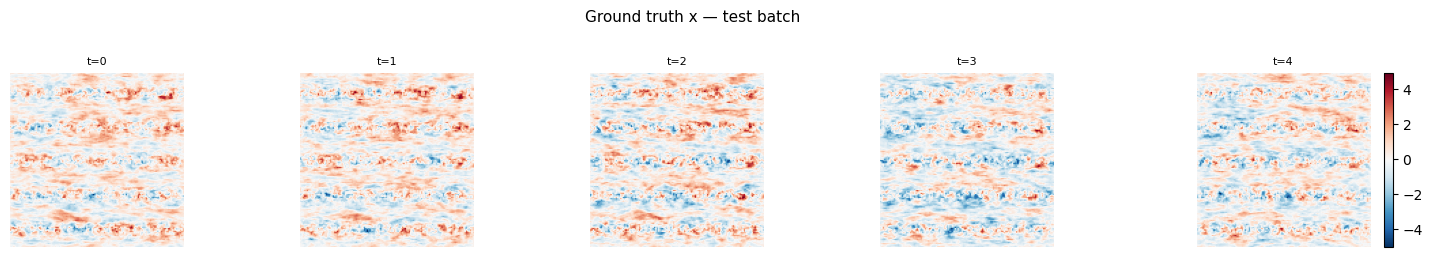

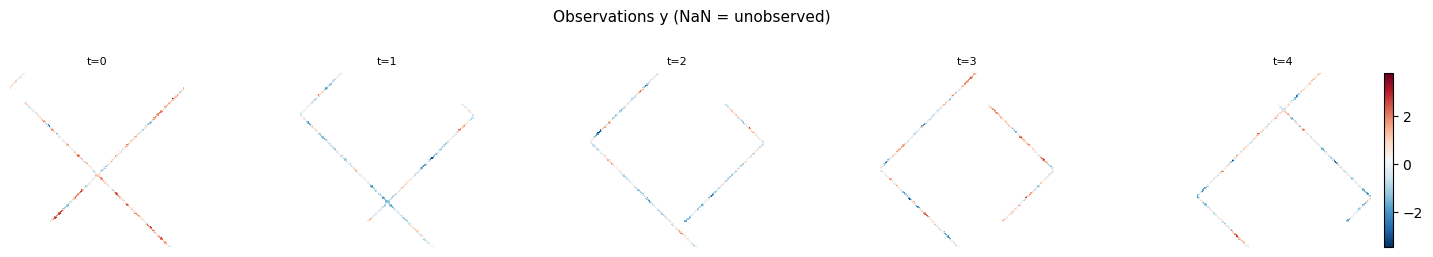

In [13]:
seed_everything(42)
batch = next(iter(datamodule.test_dataloader()))

def plot_field(arr: np.ndarray, title: str = "", vmin=None, vmax=None,
               cols: int = 5, cmap: str = "RdBu_r") -> None:
    T    = arr.shape[0]
    rows = math.ceil(T / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 2.5 * rows))
    axes = np.array(axes).ravel()
    for t in range(T):
        im = axes[t].imshow(arr[t], origin="lower", cmap=cmap, vmin=vmin, vmax=vmax)
        axes[t].set_title(f"t={t}", fontsize=8)
        axes[t].axis("off")
    for ax in axes[T:]:
        ax.axis("off")
    if title:
        fig.suptitle(title, fontsize=11, y=1.01)
    plt.colorbar(im, ax=axes[-1], fraction=0.046)
    plt.tight_layout()
    plt.show()


plot_field(batch.tgt[0].float().numpy(),   title="Ground truth x — test batch")
plot_field(batch.input[0].float().numpy(), title="Observations y (NaN = unobserved)")

### Ensemble Generation

The sampler traverses the unified time grid from $t=1$ (pure noise) down to $t=0$.  
- Steps in $[0, t_\mathrm{IC}]$: **spin-up** — `skip_spinup` smoothly blends c_skip/c_out residual toward direct output  
- Steps in $[t_\mathrm{IC}, 1]$: **physical** — model output used directly  

The full observation window $\mathbf{y}$ conditions every step.

In [14]:
N_SAMPLES = 10
# nsteps = 2*C+1 gives one step per physical slot + spin-up buffer
NSTEPS    = 3 * datamodule.window_size + 1

consistency_sampling = ConsistencySamplingAndEditingDynamicalSystems(
    sigma_min=0.002,
    sigma_max=80.0,
    sigma_data=1.0,
)

C  = datamodule.window_size
H, W = batch.tgt.shape[-2], batch.tgt.shape[-1]
y_dev = batch.input.to(device=device, dtype=dtype)

samples         = []
samples_process = []

with torch.no_grad():
    for i in range(N_SAMPLES):
        # Initial noise: single spatial field (1 channel)
        noise = torch.randn((1, 1, H, W), device=device, dtype=dtype)
        sample, sample_process = consistency_sampling(
            unet,
            noise,
            y_dev,
            nsteps=NSTEPS,
            clip_denoised=False,
            verbose=(i == 0),
        )
        samples.append(sample.float().cpu())
        samples_process.append(sample_process.float().cpu())
        print(f"  Sample {i+1}/{N_SAMPLES} done", end="\r")
print(f"\n[OK] {N_SAMPLES} ensemble members generated  (nsteps={NSTEPS})")

# samples[i]: (1, 1, H, W)
# For the physical regime we extract the C frames at physical time indices
# time grid: linspace(1, 1e-8, nsteps) — index 1..2k+1 correspond to steps
# Physical state k lives at step index 2*(C-1-k)+1 (reverse order)
print(f"\nSample shape: {samples[0].shape}")
print(f"Process shape: {samples_process[0].shape}  (nsteps+1, B=1, 1, H, W)")

  Sample 10/10 done
[OK] 10 ensemble members generated  (nsteps=16)

Sample shape: torch.Size([1, 1, 128, 128])
Process shape: torch.Size([16, 1, 1, 128, 128])  (nsteps+1, B=1, 1, H, W)
  Sample 10/10 done
[OK] 10 ensemble members generated  (nsteps=16)

Sample shape: torch.Size([1, 1, 128, 128])
Process shape: torch.Size([16, 1, 1, 128, 128])  (nsteps+1, B=1, 1, H, W)


### Transport process — sampling trajectory visualisation

Display **all diffusion steps** and then extract the **physical time steps** from the trajectory.  
The model maps noise at $t=1$ through the spin-up into the physical regime step by step.

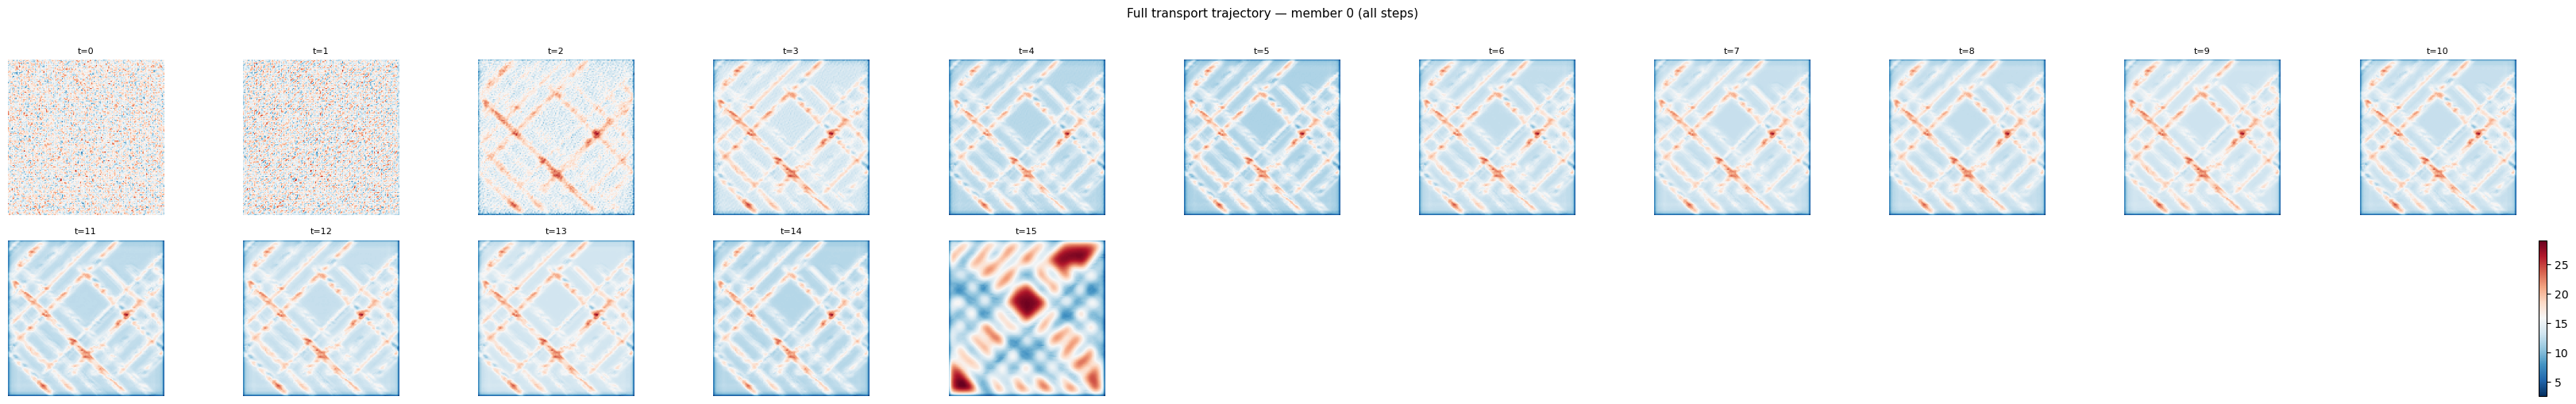

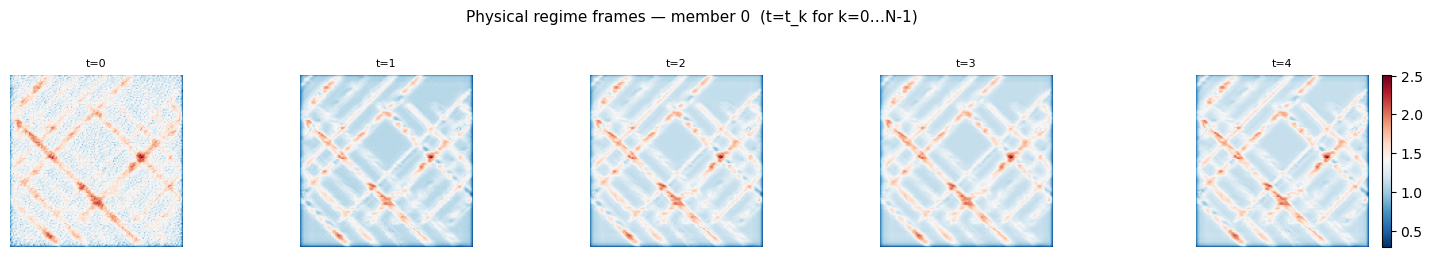

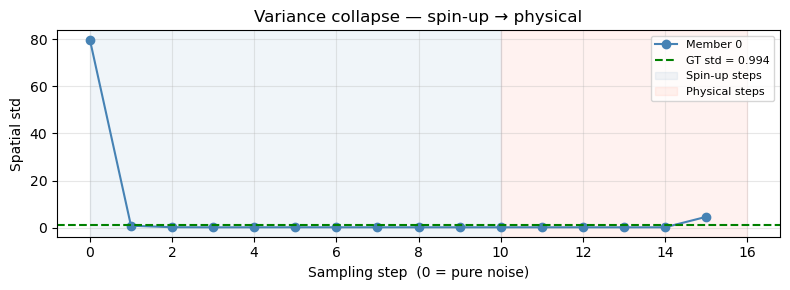

Std step 0 (noise): 79.6997   Std last step: 4.6372   GT std: 0.9939


In [15]:
# Full sampling trajectory (member 0)
proc  = samples_process[0]           # (nsteps+1, 1, 1, H, W)
nfr   = proc.shape[0]
times = torch.linspace(1.0, 1e-8, NSTEPS)   # forward-order in time

# --- All steps ---
plot_field(proc[:, 0, 0, :, :].numpy(),
           title="Full transport trajectory — member 0 (all steps)",
           cols=min(nfr, 11))

# --- Physical steps only ---
# In the sampler, times[-1] ≈ 0 (spin-up IC), times[0] = 1 (pure noise)
# Physical states appear at the end of the trajectory (low t = physical time)
phys_indices = torch.arange(2, 2 * C + 1, 2).int()   # even indices -> physical slots
if phys_indices[-1] < nfr:
    phys_frames = proc[phys_indices, 0, 0, :, :].numpy()
    plot_field(phys_frames,
               title="Physical regime frames — member 0  (t=t_k for k=0…N-1)",
               cols=C)
else:
    print("[INFO] Not enough steps to extract physical frames — increase NSTEPS.")

# --- Variance collapse ---
step_stds = np.array([
    proc[k, 0, 0, :, :].numpy().std()
    for k in range(nfr)
])
gt_std = batch.tgt[0].float().numpy().std()

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(np.arange(nfr), step_stds, marker="o", color="steelblue", label="Member 0")
ax.axhline(gt_std, color="green", linestyle="--", label=f"GT std = {gt_std:.3f}")
ax.axvspan(0, max(1, nfr - C - 1), alpha=0.08, color="steelblue", label="Spin-up steps")
ax.axvspan(max(1, nfr - C - 1), nfr, alpha=0.08, color="tomato",    label="Physical steps")
ax.set_xlabel("Sampling step  (0 = pure noise)")
ax.set_ylabel("Spatial std")
ax.set_title("Variance collapse — spin-up → physical")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Std step 0 (noise): {step_stds[0]:.4f}   Std last step: {step_stds[-1]:.4f}   GT std: {gt_std:.4f}")

### Ensemble — mean, std, error maps

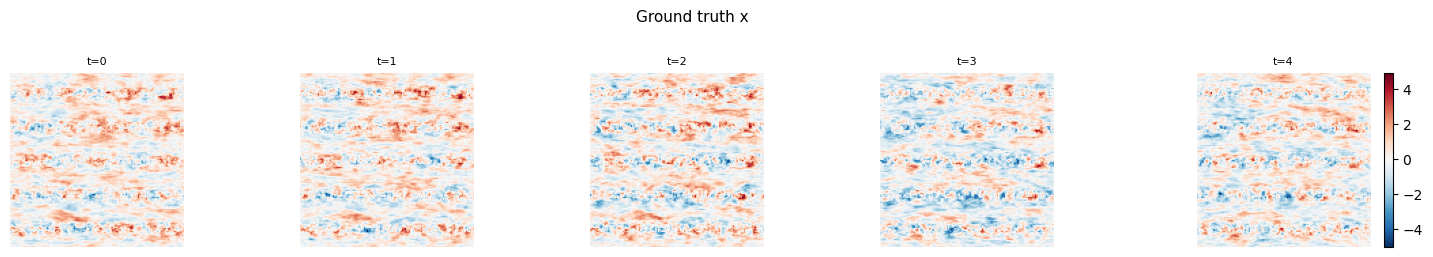

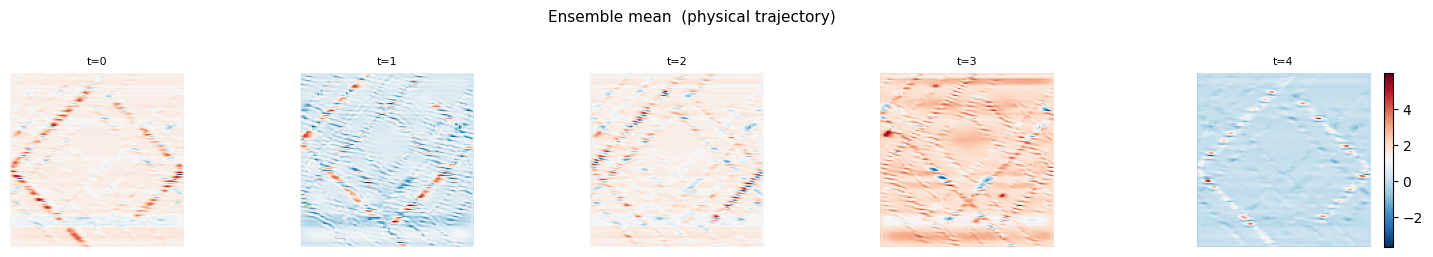

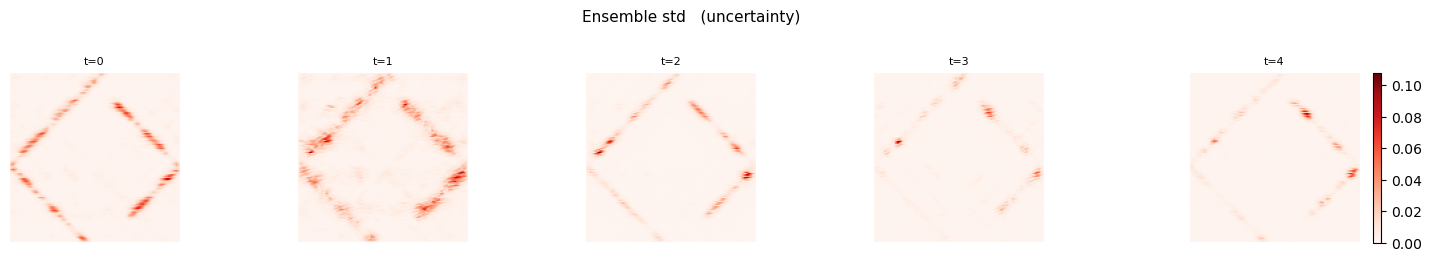

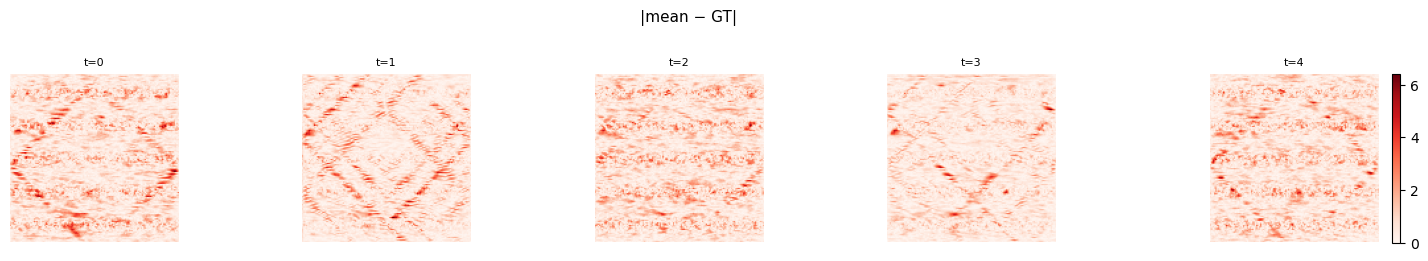

In [ ]:
# Stack samples — each sample is (1, 1, H, W) → extract spatial field
# The final state samples[i] is the model output at t→0 (IC estimate after spin-up)
# To get the physical trajectory, use the process at physical time indices
phys_idx = torch.arange(2, 2 * C + 1, 2).int()

def extract_physical_trajectory(proc_tensor: torch.Tensor) -> torch.Tensor:
    """proc_tensor: (nsteps+1, 1, 1, H, W) -> (C, H, W)"""
    if phys_idx[-1] < proc_tensor.shape[0]:
        return proc_tensor[phys_idx, 0, 0, :, :]   # (C, H, W)
    else:
        # fallback: repeat last frame
        return proc_tensor[-1:, 0, 0, :, :].expand(C, -1, -1)


traj_list = [extract_physical_trajectory(p) for p in samples_process]  # list of (C, H, W)
traj_stack = torch.stack(traj_list, dim=0).numpy()   # (N, C, H, W)

ens_mean_traj = traj_stack.mean(axis=0)   # (C, H, W)
ens_std_traj  = traj_stack.std(axis=0)    # (C, H, W)
gt_np         = batch.tgt[0].float().numpy()   # (C, H, W)

plot_field(gt_np,                                       title="Ground truth x")
plot_field(ens_mean_traj,                               title="Ensemble mean  (physical trajectory)")
plot_field(ens_std_traj,      vmin=0, cmap="Reds",      title="Ensemble std   (uncertainty)")
plot_field(np.abs(ens_mean_traj - gt_np), vmin=0, cmap="Reds", title="|mean − GT|")

## 📊 Metrics

- **μ-score** = $1 - \text{RMSE}/\sigma_\text{GT}$ (higher is better)
- **RMSE** (lower is better)
- **Spread-skill ratio** (ideal ~ 1)
- **Radial PSD** — spectral comparison vs GT and OI baseline

In [ ]:
try:
    from properscoring import crps_ensemble
    HAS_PROPERSCORING = True
except ImportError:
    HAS_PROPERSCORING = False
    print("[WARN] properscoring not installed — CRPS disabled.")

m_norm, s_norm = datamodule.norm_stats()

gt_phys       = gt_np       * s_norm + m_norm
ens_mean_phys = ens_mean_traj * s_norm + m_norm
traj_phys     = traj_stack    * s_norm + m_norm   # (N, C, H, W)

# OI baseline
start_t = datamodule.test_ds.indices[0]
ws      = datamodule.window_size
oi_phys = datamodule.oi[start_t : start_t + ws].astype(np.float32)
oi_norm = (oi_phys - m_norm) / s_norm


def compute_psd_and_lambda_x(field: np.ndarray, dx: float = 1.0):
    f = field.copy()
    f[np.isnan(f)] = 0.0
    psd_sum = sum(np.abs(np.fft.fft2(f[t])) ** 2 for t in range(f.shape[0]))
    psd_avg = psd_sum / f.shape[0]
    ny, nx  = psd_avg.shape
    yy, xx  = np.meshgrid(np.arange(ny) - ny // 2, np.arange(nx) - nx // 2, indexing="ij")
    rr      = np.sqrt(xx ** 2 + yy ** 2)
    r_max   = int(np.sqrt((ny // 2) ** 2 + (nx // 2) ** 2))
    radial_psd = np.array([
        np.mean(np.fft.fftshift(psd_avg)[(rr >= r) & (rr < r + 1)])
        if np.any((rr >= r) & (rr < r + 1)) else 0.0
        for r in range(r_max)
    ])
    threshold = 0.5 * np.max(radial_psd[1:])
    idx_50    = np.where(radial_psd < threshold)[0]
    lambda_x  = (nx * dx) / idx_50[0] if len(idx_50) > 0 else np.nan
    return lambda_x, radial_psd


def metrics_vs_gt(pred, gt, label, dx=1.0):
    gt_std   = np.nanstd(gt)
    rmse_v   = np.sqrt(np.nanmean((pred - gt) ** 2))
    mu       = 1.0 - rmse_v / gt_std
    lx_gt,   psd_gt   = compute_psd_and_lambda_x(gt,   dx=dx)
    lx_pred, psd_pred = compute_psd_and_lambda_x(pred, dx=dx)
    spectral = np.corrcoef(psd_gt[:len(psd_gt) // 2], psd_pred[:len(psd_pred) // 2])[0, 1]
    return dict(Method=label, mu_score=mu, RMSE=rmse_v,
                lambda_x_GT=lx_gt, lambda_x_pred=lx_pred, spectral_corr=spectral), psd_pred, psd_gt


row_cm, psd_cm, psd_gt_rad = metrics_vs_gt(ens_mean_phys, gt_phys, "DynConsistency (mean traj)")
row_oi, psd_oi, _           = metrics_vs_gt(oi_phys,        gt_phys, "OI baseline")

rmse_cm_norm = np.sqrt(np.nanmean((ens_mean_traj - gt_np) ** 2))
rmse_oi_norm = np.sqrt(np.nanmean((oi_norm        - gt_np) ** 2))
print(f"RMSE DynConsistency (normalised): {rmse_cm_norm:.4f}")
print(f"RMSE OI             (normalised): {rmse_oi_norm:.4f}")

rmse_det = np.sqrt(np.nanmean((ens_mean_phys - gt_phys) ** 2))
spread   = np.nanmean(np.std(traj_phys, axis=0))
print(f"\nEnsemble spread (mean std) : {spread:.4f}")
print(f"RMSE (ensemble mean)       : {rmse_det:.4f}")
print(f"Spread-skill ratio         : {spread / max(rmse_det, 1e-8):.4f}  (ideal ~ 1.0)")

if HAS_PROPERSCORING:
    crps_vals = [
        crps_ensemble(gt_phys[t, i, j], traj_phys[:, t, i, j])
        for t in range(gt_phys.shape[0])
        for i in range(gt_phys.shape[1])
        for j in range(gt_phys.shape[2])
        if not np.isnan(gt_phys[t, i, j])
    ]
    print(f"CRPS mean (ensemble)       : {np.mean(crps_vals):.4f}")

df = pd.DataFrame([row_cm, row_oi]).set_index("Method")
for col in ["mu_score", "RMSE", "spectral_corr"]:
    df[col] = df[col].map("{:.4f}".format)
for col in ["lambda_x_GT", "lambda_x_pred"]:
    df[col] = df[col].map(lambda v: f"{v:.2f}" if not np.isnan(v) else "N/A")
print("\n## Performance — DynConsistency vs OI (SPDE dataset)\n")
print(df.to_markdown())
display(df)

/tmp/ipykernel_3872721/3337399815.py:37: RuntimeWarning: divide by zero encountered in divide
  lambda_x  = (nx * dx) / idx_50[0] if len(idx_50) > 0 else np.nan


RMSE DynConsistency (normalised): 1.1622
RMSE OI             (normalised): 0.8942

Ensemble spread (mean std) : 0.0031
RMSE (ensemble mean)       : 0.2896
Spread-skill ratio         : 0.0107  (ideal ~ 1.0)
CRPS mean (ensemble)       : 0.2210

## Performance — DynConsistency vs OI (SPDE dataset)

| Method                     |   mu_score |   RMSE |   lambda_x_GT |   lambda_x_pred |   spectral_corr |
|:---------------------------|-----------:|-------:|--------------:|----------------:|----------------:|
| DynConsistency (mean traj) |    -0.1693 | 0.2896 |           inf |           42.67 |          0.5841 |
| OI baseline                |     0.1004 | 0.2228 |           inf |          inf    |          0.99   |
CRPS mean (ensemble)       : 0.2210

## Performance — DynConsistency vs OI (SPDE dataset)

| Method                     |   mu_score |   RMSE |   lambda_x_GT |   lambda_x_pred |   spectral_corr |
|:---------------------------|-----------:|-------:|--------------:|----------------:|-

,mu_score,RMSE,lambda_x_GT,lambda_x_pred,spectral_corr
Method,,,,,
DynConsistency (mean traj),-0.1693,0.2896,inf,42.67,0.5841
OI baseline,0.1004,0.2228,inf,inf,0.9900


### Radial PSD

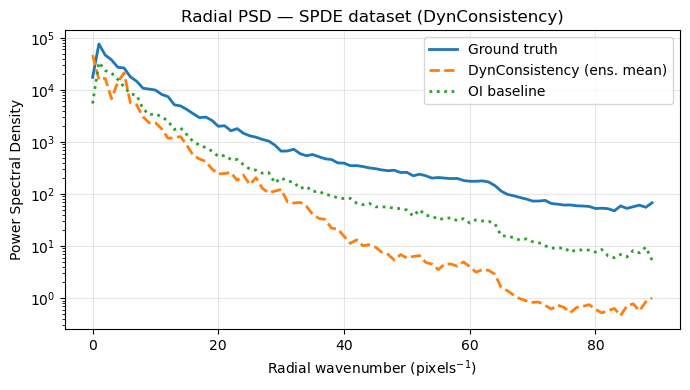

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(psd_gt_rad, label="Ground truth",               linewidth=2)
ax.semilogy(psd_cm,      label="DynConsistency (ens. mean)", linewidth=2, linestyle="--")
ax.semilogy(psd_oi,      label="OI baseline",                linewidth=2, linestyle=":")
ax.set_xlabel("Radial wavenumber (pixels$^{-1}$)")
ax.set_ylabel("Power Spectral Density")
ax.set_title("Radial PSD — SPDE dataset (DynConsistency)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Visual Comparison — GT / OI / DynConsistency per physical time step

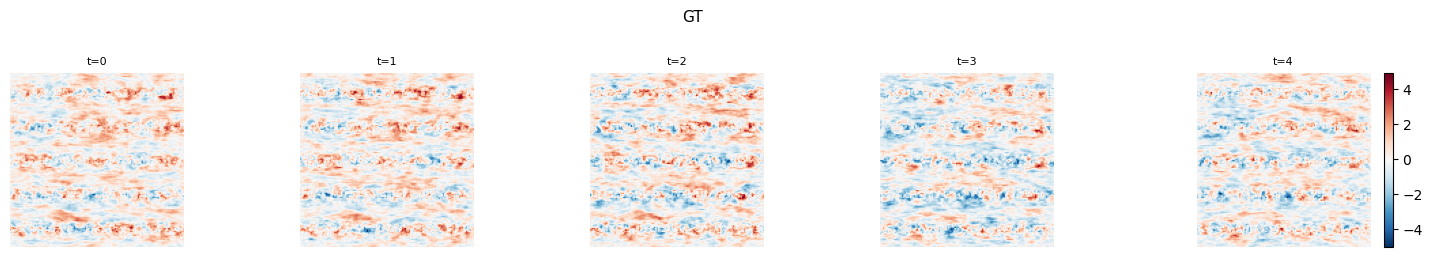

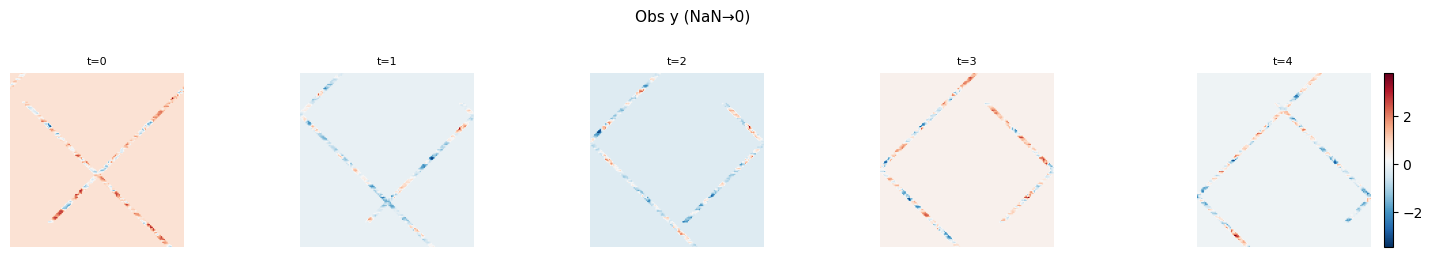

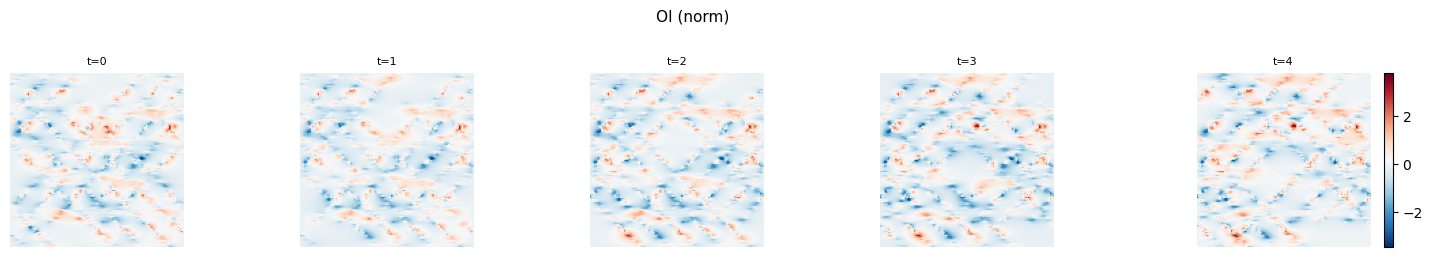

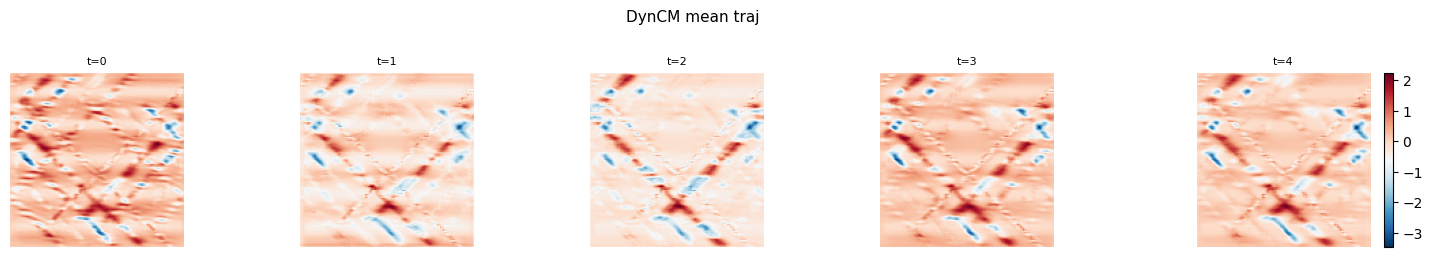

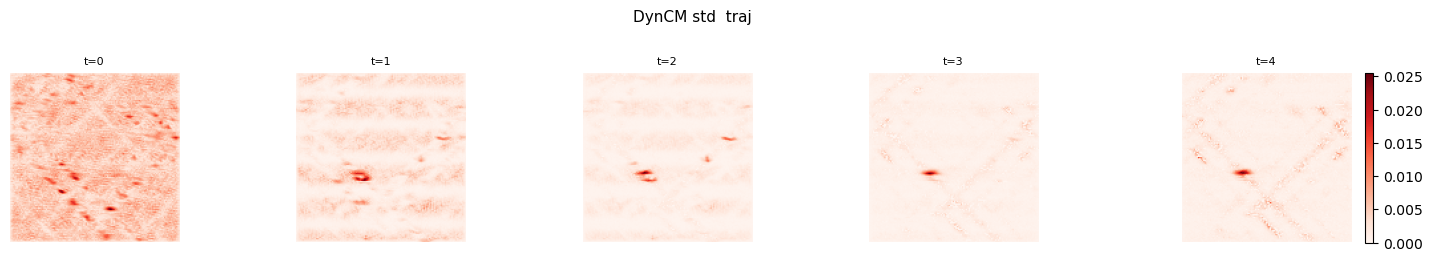

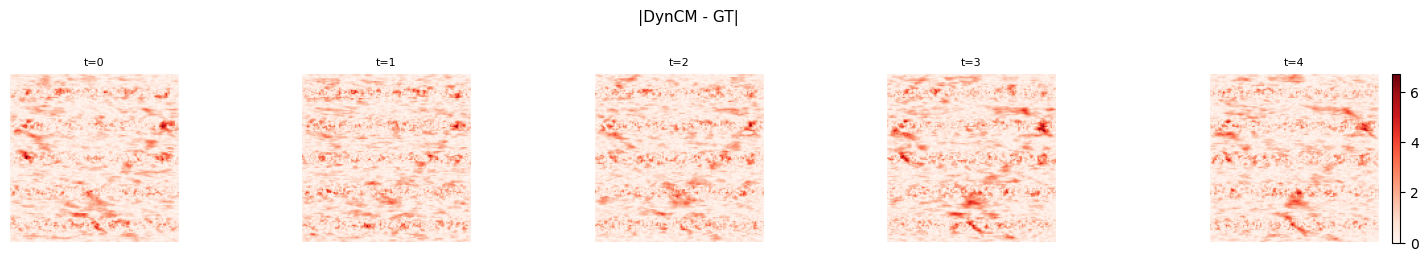

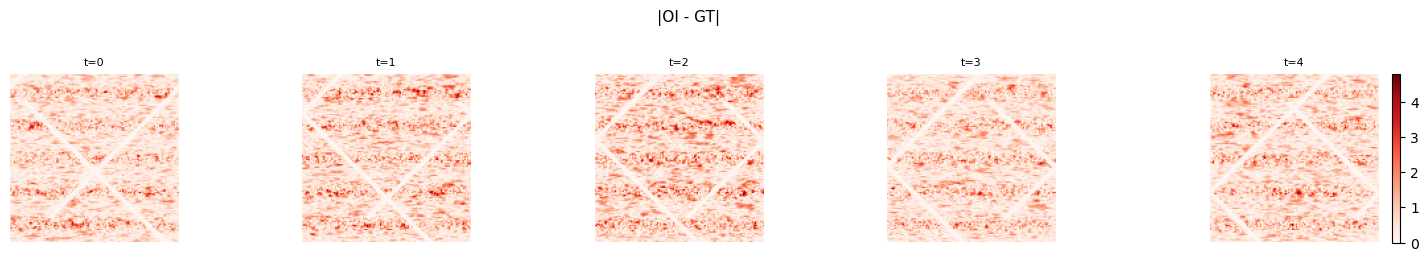

In [ ]:
rows_data = {
    "GT":                gt_np,
    "Obs y (NaN→0)":     np.nan_to_num(batch.input[0].float().numpy(), nan=0.0),
    "OI (norm)":         oi_norm,
    "DynCM mean traj":   ens_mean_traj,
    "DynCM std  traj":   ens_std_traj,
    "|DynCM - GT|":      np.abs(ens_mean_traj - gt_np),
    "|OI - GT|":         np.abs(oi_norm - gt_np),
}

for label, arr in rows_data.items():
    vmin_v = 0 if ("std" in label or "|" in label) else None
    cmap_v = "Reds" if ("std" in label or "|" in label) else "RdBu_r"
    plot_field(arr, title=label, vmin=vmin_v, cmap=cmap_v, cols=C)